# NB11 — Representative Hours Table

Reduces 8,760 hours of EIA-930 hourly demand data to 16 representative hours
via k-means clustering. Produces the E4ST hours table and per-BA load inputs.

**Inputs:**
- `data/processed/eia930_raw.parquet` — structure detection; demand fetched via API if interchange format
- `data/processed/ba_territories.geojson` — BA code alignment check
- `data/processed/network_metadata.json` — metadata accumulation

**Outputs:**
- `data/processed/e4st_hours.csv` — 16-row hours table with weights
- `data/processed/e4st_load_by_hour.parquet` — 16 × N_BA load matrix
- `data/processed/figures/11_representative_hours.png` — 4×4 centroid-day plot

In [1]:
import sys, json, time, calendar
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

sys.path.insert(0, str(Path().resolve().parent / "src"))
from utils import eia_get

PROJECT_ROOT  = Path().resolve().parent
PROCESSED     = PROJECT_ROOT / "data" / "processed"
RAW           = PROJECT_ROOT / "data" / "raw"

YEAR          = 2023
PAGE_SIZE     = 5000
DEMAND_CACHE  = RAW / "eia930_demand_2023.parquet"
K_VALUES      = [8, 16, 24]
K_FINAL       = 16
RANDOM_STATE  = 42
EXPECTED_HOURS = 8760   # 2023 is not a leap year

print("Project root:", PROJECT_ROOT)
print("Demand cache:", DEMAND_CACHE)

Project root: /Users/dylanhartman/Library/CloudStorage/OneDrive-UniversityofWyoming/Research/Energy Modeling/energy-map
Demand cache: /Users/dylanhartman/Library/CloudStorage/OneDrive-UniversityofWyoming/Research/Energy Modeling/energy-map/data/raw/eia930_demand_2023.parquet


In [2]:
# --- Load raw parquet and detect data structure ---
raw_parquet = PROCESSED / "eia930_raw.parquet"
raw_df = pd.read_parquet(raw_parquet)

print(f"eia930_raw.parquet  shape : {raw_df.shape}")
print(f"Columns             : {list(raw_df.columns)}")

# Detect interchange vs demand structure
if "toba" in raw_df.columns:
    n_bas = raw_df["fromba"].nunique()
    periods = raw_df["period"] if "period" in raw_df.columns else raw_df.get("Data Date")
    if "period" in raw_df.columns:
        p_min = pd.to_datetime(raw_df["period"]).min()
        p_max = pd.to_datetime(raw_df["period"]).max()
    else:
        p_min, p_max = raw_df["Data Date"].min(), raw_df["Data Date"].max()
    print(f"Date range          : {p_min}  →  {p_max}")
    print(f"Unique fromba BAs   : {n_bas}")
    print()
    print("Structure: BA-to-BA INTERCHANGE flows (fromba → toba)")
    print("Net load cannot be derived from interchange alone.")
    print("Will fetch hourly demand (type=D) from EIA API and cache to:")
    print(f"  {DEMAND_CACHE}")
    DATA_TYPE = "interchange"
else:
    # Already demand format
    raw_df["period"] = pd.to_datetime(raw_df["period"], utc=True)
    print(f"Date range: {raw_df['period'].min()} → {raw_df['period'].max()}")
    print(f"BA count: {raw_df['respondent'].nunique()}")
    print("Structure: demand data — skipping API fetch")
    DATA_TYPE = "demand"

eia930_raw.parquet  shape : (2584201, 9)
Columns             : ['fromba', 'Data Date', 'Hour Number', 'toba', 'value', 'Local Time at End of Hour', 'period', 'Region', 'DIBA_Region']


Date range          : 2023-01-01 06:00:00+00:00  →  2024-01-01 08:00:00+00:00
Unique fromba BAs   : 62

Structure: BA-to-BA INTERCHANGE flows (fromba → toba)
Net load cannot be derived from interchange alone.
Will fetch hourly demand (type=D) from EIA API and cache to:
  /Users/dylanhartman/Library/CloudStorage/OneDrive-UniversityofWyoming/Research/Energy Modeling/energy-map/data/raw/eia930_demand_2023.parquet


In [3]:
# --- Fetch EIA-930 demand data (type=D) if not already cached ---

def _fetch_demand_month(year: int, month: int) -> list:
    """Paginate one calendar month of hourly demand data from EIA-930."""
    _, last_day = calendar.monthrange(year, month)
    start = f"{year}-{month:02d}-01T00"
    end   = f"{year}-{month:02d}-{last_day:02d}T23"
    records, offset = [], 0
    while True:
        resp = eia_get("electricity/rto/region-data/data", {
            "frequency":            "hourly",
            "data[0]":              "value",
            "facets[type][0]":      "D",
            "start":                start,
            "end":                  end,
            "sort[0][column]":      "period",
            "sort[0][direction]":   "asc",
            "length":               PAGE_SIZE,
            "offset":               offset,
        })
        batch = resp["response"]["data"]
        records.extend(batch)
        total = int(resp["response"]["total"])
        offset += len(batch)
        if offset >= total or not batch:
            break
    return records

if DATA_TYPE == "demand":
    # raw_df already contains demand rows; convert to the same schema
    demand_df = raw_df.rename(columns={"fromba": "respondent"})
    demand_df["value"] = pd.to_numeric(demand_df["value"], errors="coerce")
elif DEMAND_CACHE.exists():
    print(f"Loading demand cache: {DEMAND_CACHE}")
    demand_df = pd.read_parquet(DEMAND_CACHE)
    demand_df["period"] = pd.to_datetime(demand_df["period"], utc=True)
    print(f"Cached shape  : {demand_df.shape}")
    print(f"BA count      : {demand_df['respondent'].nunique()}")
    print(f"Period range  : {demand_df['period'].min()}  →  {demand_df['period'].max()}")
else:
    print(f"Fetching {YEAR} hourly demand from EIA API (12 months × paginated)...")
    all_records = []
    for month in range(1, 13):
        records = _fetch_demand_month(YEAR, month)
        all_records.extend(records)
        print(f"  {YEAR}-{month:02d}  rows: {len(records):>7,}   cumulative: {len(all_records):>8,}")
        time.sleep(0.3)

    demand_df = pd.DataFrame(all_records)
    demand_df["value"]  = pd.to_numeric(demand_df["value"],  errors="coerce")
    demand_df["period"] = pd.to_datetime(demand_df["period"], utc=True)
    RAW.mkdir(parents=True, exist_ok=True)
    demand_df.to_parquet(DEMAND_CACHE, index=False)
    mb = DEMAND_CACHE.stat().st_size / 1e6
    print(f"\nCached → {DEMAND_CACHE}  ({mb:.2f} MB)")

print(f"\nDemand data shape : {demand_df.shape}")
print(f"BA count          : {demand_df['respondent'].nunique()}")
print(f"Period range      : {demand_df['period'].min()}  →  {demand_df['period'].max()}")
print(f"Null value rate   : {demand_df['value'].isna().mean():.2%}")

Fetching 2023 hourly demand from EIA API (12 months × paginated)...


  2023-01  rows:  49,848   cumulative:   49,848


  2023-02  rows:  45,024   cumulative:   94,872


  2023-03  rows:  49,728   cumulative:  144,600


  2023-04  rows:  48,240   cumulative:  192,840


...

  2023-09  rows:  48,240   cumulative:  438,864


  2023-10  rows:  49,848   cumulative:  488,712


  2023-11  rows:  48,067   cumulative:  536,779


  2023-12  rows:  49,848   cumulative:  586,627



Cached → /Users/dylanhartman/Library/CloudStorage/OneDrive-UniversityofWyoming/Research/Energy Modeling/energy-map/data/raw/eia930_demand_2023.parquet  (1.77 MB)

Demand data shape : (586627, 7)
BA count          : 67
Period range      : 2023-01-01 00:00:00+00:00  →  2023-12-31 23:00:00+00:00
Null value rate   : 0.07%


In [4]:
# --- Pivot to wide (8760 × N_BA) matrix ---

# Expected UTC hourly index for 2023
year_start = pd.Timestamp(f"{YEAR}-01-01T00:00:00", tz="UTC")
year_end   = pd.Timestamp(f"{YEAR}-12-31T23:00:00", tz="UTC")
expected_idx = pd.date_range(start=year_start, end=year_end, freq="h")
assert len(expected_idx) == EXPECTED_HOURS, f"Expected {EXPECTED_HOURS} h, got {len(expected_idx)}"

# Clip to exact year window
src = demand_df.copy()
src["period"] = pd.to_datetime(src["period"], utc=True)
src = src[(src["period"] >= year_start) & (src["period"] <= year_end)].copy()

# Check and remove duplicates
dupes = src.duplicated(subset=["period", "respondent"]).sum()
if dupes:
    print(f"WARNING: {dupes} duplicate (period, respondent) pairs — keeping first occurrence")
    src = src.drop_duplicates(subset=["period", "respondent"], keep="first")

# Pivot
wide = src.pivot(index="period", columns="respondent", values="value")
wide.columns.name = None
wide.index.name   = "hour"

# Assert or repair row count
if len(wide) != EXPECTED_HOURS:
    print(f"WARNING: Got {len(wide)} unique hours, expected {EXPECTED_HOURS} — reindexing (pads missing with NaN)")
    wide = wide.reindex(expected_idx)
else:
    print(f"Row count: {len(wide)}  ✓  matches {EXPECTED_HOURS}")

print(f"Pivot shape (pre-clean): {wide.shape}")
print(f"BAs in pivot: {wide.shape[1]}")

# --- BA code alignment check vs ba_territories ---
territories = gpd.read_file(PROCESSED / "ba_territories.geojson")
terr_bas    = set(territories["ba_code"].dropna())
demand_bas  = set(wide.columns)

unmatched_in_demand = sorted(demand_bas - terr_bas)
unmatched_in_terr   = sorted(terr_bas - demand_bas)

if unmatched_in_demand:
    print(f"\nWARNING: {len(unmatched_in_demand)} BA(s) in demand NOT in ba_territories "
          f"(will keep — may be sub-BAs or regions):")
    for b in unmatched_in_demand:
        print(f"  {b}")
if unmatched_in_terr:
    print(f"\nNote: {len(unmatched_in_terr)} BA(s) in ba_territories with no demand data "
          f"(typically small/foreign BAs):")
    print(f"  {unmatched_in_terr[:15]}{'...' if len(unmatched_in_terr) > 15 else ''}")

Row count: 8760  ✓  matches 8760
Pivot shape (pre-clean): (8760, 67)
BAs in pivot: 67



  CAL
  CAR
  CENT
  EPE
  FLA
  MIDA
  MIDW
  NE
  NW
  NWMT
  NY
  SE
  SW
  TEN
  TEX
  US48

Note: 34 BA(s) in ba_territories with no demand data (typically small/foreign BAs):
  ['AEC', 'AESO', 'AMPL', 'AVRN', 'BCHA', 'BCTC', 'CEA', 'CFE', 'DEAA', 'EEI', 'EKPC', 'ELE', 'GLHB', 'GRID', 'GRIF']...


In [5]:
# --- Drop BAs with >10% missing; interpolate remaining gaps ---

missing_rate = wide.isna().mean()
drop_bas = missing_rate[missing_rate > 0.10].index.tolist()

if drop_bas:
    print(f"Dropping {len(drop_bas)} BA(s) with >10% missing hourly observations:")
    for ba in sorted(drop_bas):
        print(f"  {ba:12s}  {missing_rate[ba]:.1%} missing  ({int(missing_rate[ba]*EXPECTED_HOURS)} h)")
    wide = wide.drop(columns=drop_bas)
else:
    print("No BAs exceed 10% missing threshold.")

# Interpolate and flag long gaps
long_gap_warnings = []
for ba in wide.columns:
    s = wide[ba]
    if s.isna().any():
        # Identify gap lengths using run-length encoding on the NaN mask
        null_mask = s.isna()
        run_id = (null_mask != null_mask.shift()).cumsum()
        gap_lengths = null_mask.groupby(run_id).sum()  # hours per gap
        max_gap = int(gap_lengths[gap_lengths > 0].max()) if (gap_lengths > 0).any() else 0
        n_long  = int((gap_lengths > 6).sum())
        if n_long:
            long_gap_warnings.append(
                f"{ba}: {n_long} gap(s) > 6 h  (max gap = {max_gap} h)"
            )
        wide[ba] = s.interpolate(method="time").ffill().bfill()

if long_gap_warnings:
    print(f"\nDATA QUALITY — gaps > 6 consecutive hours ({len(long_gap_warnings)} BA(s)):")
    for w in long_gap_warnings:
        print(f"  {w}")
else:
    print("No gaps > 6 hours detected.")

remaining_nulls = wide.isna().sum().sum()
print(f"\nPost-interpolation nulls : {remaining_nulls}")
print(f"Final matrix shape       : {wide.shape}")

# Summary: missing data overview
print("\nMissing-data summary (BA-level, pre-interpolation):")
miss_summary = missing_rate[missing_rate > 0].sort_values(ascending=False)
if len(miss_summary):
    for ba, r in miss_summary.items():
        print(f"  {ba:12s}  {r:.3%}")
else:
    print("  (no missing values)")

N_BA = wide.shape[1]
print(f"\nN_BA used for clustering: {N_BA}")

No BAs exceed 10% missing threshold.

DATA QUALITY — gaps > 6 consecutive hours (10 BA(s)):
  BPAT: 1 gap(s) > 6 h  (max gap = 24 h)
  FPL: 3 gap(s) > 6 h  (max gap = 48 h)
  IID: 2 gap(s) > 6 h  (max gap = 24 h)
  LDWP: 1 gap(s) > 6 h  (max gap = 49 h)
  PJM: 1 gap(s) > 6 h  (max gap = 25 h)
  PSCO: 2 gap(s) > 6 h  (max gap = 144 h)
  SCEG: 2 gap(s) > 6 h  (max gap = 49 h)
  SEC: 2 gap(s) > 6 h  (max gap = 73 h)
  TEC: 2 gap(s) > 6 h  (max gap = 18 h)
  TEPC: 1 gap(s) > 6 h  (max gap = 72 h)

Post-interpolation nulls : 0
Final matrix shape       : (8760, 67)

Missing-data summary (BA-level, pre-interpolation):
  PSCO          1.918%
  FPL           1.130%
  SEC           1.096%
  SCEG          0.833%
  TEPC          0.822%
  LDWP          0.559%
  IID           0.548%
  PJM           0.285%
  TEC           0.285%
  BPAT          0.274%
  FMPP          0.080%
  CISO          0.023%
  HST           0.023%
  EPE           0.011%
  MIDA          0.011%

N_BA used for clustering: 67


In [6]:
# --- Normalize and run k-means for k = 8, 16, 24 ---

# Normalize: each BA's load series divided by its annual mean
# (clustering finds shape patterns, not magnitude patterns)
ba_means = wide.mean(axis=0)
zero_mean_bas = ba_means[ba_means == 0].index.tolist()
if zero_mean_bas:
    print(f"WARNING: Dropping {len(zero_mean_bas)} BA(s) with zero mean load: {zero_mean_bas}")
    wide     = wide.drop(columns=zero_mean_bas)
    ba_means = ba_means.drop(index=zero_mean_bas)
    N_BA     = wide.shape[1]

normalized = wide.div(ba_means, axis=1)
X = normalized.values.astype(np.float64)  # shape (8760, N_BA)
print(f"Clustering matrix shape : {X.shape}  (rows=hours, cols=BAs)")
print(f"Any NaN in X            : {np.isnan(X).any()}")
print()

# Fit k-means for each candidate k
wcss   = {}
models = {}
print(f"{'k':>4}   {'WCSS':>14}   {'Notes'}")
print("-" * 50)
for k in K_VALUES:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
    km.fit(X)
    wcss[k]   = km.inertia_
    models[k] = km
    print(f"{k:>4}   {km.inertia_:>14,.1f}")

print()
print("Elbow analysis (WCSS % drop per step):")
for i in range(len(K_VALUES) - 1):
    k0, k1 = K_VALUES[i], K_VALUES[i + 1]
    drop_pct = (wcss[k0] - wcss[k1]) / wcss[k0] * 100
    print(f"  k={k0} → k={k1}: {drop_pct:.1f}% reduction")

print(f"\n→ Using k={K_FINAL}: balances pattern resolution vs E4ST solve time")
km_final = models[K_FINAL]
labels   = km_final.labels_   # shape (8760,)
print(f"Cluster sizes (hours per cluster):")
sizes = pd.Series(labels).value_counts().sort_index()
print(sizes.to_string())

Clustering matrix shape : (8760, 67)  (rows=hours, cols=BAs)
Any NaN in X            : False

   k             WCSS   Notes
--------------------------------------------------
   8         18,115.4


  16         11,494.9


  24          8,983.7

Elbow analysis (WCSS % drop per step):
  k=8 → k=16: 36.5% reduction
  k=16 → k=24: 21.8% reduction

→ Using k=16: balances pattern resolution vs E4ST solve time
Cluster sizes (hours per cluster):
0     1073
1        1
2      960
3      698
4     1623
5        1
6        2
7        3
8     1047
9       46
10       7
11      11
12     936
13       2
14    1141
15    1209


In [7]:
# --- Cluster analysis: centroid hours, weights, season/time-of-day, outliers ---

MONTH_TO_SEASON = {}
for _season, _months in {"DJF": [12,1,2], "MAM": [3,4,5], "JJA": [6,7,8], "SON": [9,10,11]}.items():
    for _m in _months:
        MONTH_TO_SEASON[_m] = _season

def _time_of_day(hour_utc: int) -> str:
    if hour_utc < 6:   return "overnight"
    if hour_utc < 12:  return "morning"
    if hour_utc < 18:  return "afternoon"
    return "evening"

hours_idx   = wide.index          # UTC DatetimeIndex, 8760 entries
all_dists   = []                  # for global outlier table
cluster_info = []

for c in range(K_FINAL):
    mask         = (labels == c)
    cluster_X    = X[mask]                    # (n_c, N_BA)
    centroid     = km_final.cluster_centers_[c]
    dists        = np.linalg.norm(cluster_X - centroid, axis=1)

    # Actual centroid hour = closest data point to centroid
    local_best   = int(np.argmin(dists))
    global_idx   = np.where(mask)[0]
    centroid_ts  = hours_idx[global_idx[local_best]]

    # Track all distances for outlier report
    for gi, d in zip(global_idx, dists):
        all_dists.append({"cluster": c, "dist": d, "global_idx": gi,
                          "hour_ts": hours_idx[gi]})

    weight       = mask.sum() / EXPECTED_HOURS
    national_mw  = float(wide.loc[centroid_ts].sum())

    cluster_info.append({
        "cluster":        c,
        "centroid_ts":    centroid_ts,
        "weight":         weight,
        "season":         MONTH_TO_SEASON[centroid_ts.month],
        "time_of_day":    _time_of_day(centroid_ts.hour),
        "national_load_mw": national_mw,
        "n_hours":        int(mask.sum()),
    })

# Print top-5 outlier hours globally
outlier_df = (pd.DataFrame(all_dists)
                .nlargest(5, "dist")
                .reset_index(drop=True))
print("Top 5 outlier hours (largest distance to cluster centroid):")
print(f"  {'Hour (UTC)':<25}  {'Cluster':>7}  {'Dist':>8}  {'Nat. Load (GW)':>15}")
print("  " + "-" * 60)
for _, row in outlier_df.iterrows():
    ts = row["hour_ts"]
    nl = wide.loc[ts].sum() / 1000
    print(f"  {str(ts):<25}  {int(row['cluster']):>7}  {row['dist']:>8.3f}  {nl:>15,.1f}")

print()
print(f"{'Cluster':<8} {'Centroid (UTC)':<22} {'Season':<6} {'Time-of-day':<12} "
      f"{'Weight':<8} {'N_hrs':<7} {'Nat Load GW':>12}")
print("-" * 80)
for ci in sorted(cluster_info, key=lambda x: x["centroid_ts"]):
    print(f"{ci['cluster']:<8} {str(ci['centroid_ts']):<22} {ci['season']:<6} "
          f"{ci['time_of_day']:<12} {ci['weight']:.4f}   {ci['n_hours']:<7} "
          f"{ci['national_load_mw']/1000:>12,.1f}")

Top 5 outlier hours (largest distance to cluster centroid):
  Hour (UTC)                 Cluster      Dist   Nat. Load (GW)
  ------------------------------------------------------------
  2023-10-25 17:00:00+00:00        8    13.550          1,309.0
  2023-12-22 11:00:00+00:00        6    11.356          1,253.8
  2023-08-12 10:00:00+00:00        6    11.356          1,296.4
  2023-08-07 19:00:00+00:00        3    10.147          2,004.0
  2023-09-25 16:00:00+00:00       12     9.483          1,448.9

Cluster  Centroid (UTC)         Season Time-of-day  Weight   N_hrs    Nat Load GW
--------------------------------------------------------------------------------
13       2023-01-24 16:00:00+00:00 DJF    afternoon    0.0002   2            1,560.0
10       2023-01-24 21:00:00+00:00 DJF    evening      0.0008   7            1,423.7
4        2023-02-20 16:00:00+00:00 DJF    afternoon    0.1853   1623         1,351.1
11       2023-02-27 01:00:00+00:00 DJF    overnight    0.0013   11        

In [8]:
# --- Build and save e4st_hours.csv ---

# Sort clusters chronologically by centroid_ts, assign hour_id 1..16
sorted_ci = sorted(cluster_info, key=lambda x: x["centroid_ts"])

# Build mapping: cluster index → hour_id
cluster_to_hour_id = {ci["cluster"]: (i + 1) for i, ci in enumerate(sorted_ci)}

rows = []
for i, ci in enumerate(sorted_ci):
    rows.append({
        "hour_id":          i + 1,
        "weight":           round(ci["weight"], 8),
        "season":           ci["season"],
        "time_of_day":      ci["time_of_day"],
        "national_load_mw": round(ci["national_load_mw"], 1),
        "notes":            ci["centroid_ts"].strftime("%Y-%m-%dT%H:00Z"),
    })

hours_df = pd.DataFrame(rows)

out_hours = PROCESSED / "e4st_hours.csv"
hours_df.to_csv(out_hours, index=False)

print(f"Saved: {out_hours}  ({out_hours.stat().st_size / 1e3:.1f} KB)")
print(f"Sum of weights: {hours_df['weight'].sum():.8f}  (expected ≈ 1.0)")
print()
print(hours_df.to_string(index=False))

Saved: /Users/dylanhartman/Library/CloudStorage/OneDrive-UniversityofWyoming/Research/Energy Modeling/energy-map/data/processed/e4st_hours.csv  (0.9 KB)
Sum of weights: 1.00000002  (expected ≈ 1.0)

 hour_id   weight season time_of_day  national_load_mw             notes
       1 0.000228    DJF   afternoon         1560030.0 2023-01-24T16:00Z
       2 0.000799    DJF     evening         1423699.0 2023-01-24T21:00Z
       3 0.185274    DJF   afternoon         1351107.0 2023-02-20T16:00Z
       4 0.001256    DJF   overnight         1417574.0 2023-02-27T01:00Z
       5 0.005251    MAM     evening         1282092.0 2023-03-19T19:00Z
       6 0.138014    MAM     morning         1115358.0 2023-04-07T07:00Z
       7 0.119521    MAM     evening         1342083.0 2023-05-04T20:00Z
       8 0.000342    MAM   overnight         1446615.0 2023-05-11T02:00Z
       9 0.000114    MAM   afternoon         1355285.0 2023-05-19T16:00Z
      10 0.000114    JJA   overnight         5134957.0 2023-06-13T02:00

In [9]:
# --- Build and save e4st_load_by_hour.parquet ---
# For each representative hour (centroid_ts), record actual BA-level load in MW

load_rows = []
for ci in cluster_info:
    h_id = cluster_to_hour_id[ci["cluster"]]
    ts   = ci["centroid_ts"]
    hour_load = wide.loc[ts]           # Series: ba_code → MW
    for ba_code, load_mw in hour_load.items():
        load_rows.append({
            "hour_id": h_id,
            "ba_code": ba_code,
            "load_mw": round(float(load_mw), 2),
        })

load_df = pd.DataFrame(load_rows)

out_load = PROCESSED / "e4st_load_by_hour.parquet"
load_df.to_parquet(out_load, index=False)

mb = out_load.stat().st_size / 1e6
expected_rows = K_FINAL * N_BA
print(f"Saved: {out_load}  ({mb:.3f} MB)")
print(f"Shape: {load_df.shape}  (expected {expected_rows} rows = {K_FINAL} hours × {N_BA} BAs)")
print(f"Null load_mw: {load_df['load_mw'].isna().sum()}")
print(f"\nSample (hour_id=1):")
print(load_df[load_df["hour_id"] == 1].head(5).to_string(index=False))

Saved: /Users/dylanhartman/Library/CloudStorage/OneDrive-UniversityofWyoming/Research/Energy Modeling/energy-map/data/processed/e4st_load_by_hour.parquet  (0.009 MB)
Shape: (1072, 3)  (expected 1072 rows = 16 hours × 67 BAs)
Null load_mw: 0

Sample (hour_id=1):
 hour_id ba_code  load_mw
       1    AECI   3534.0
       1     AVA   1901.0
       1    AZPS   4484.0
       1    BANC   2248.0
       1    BPAT   8749.0


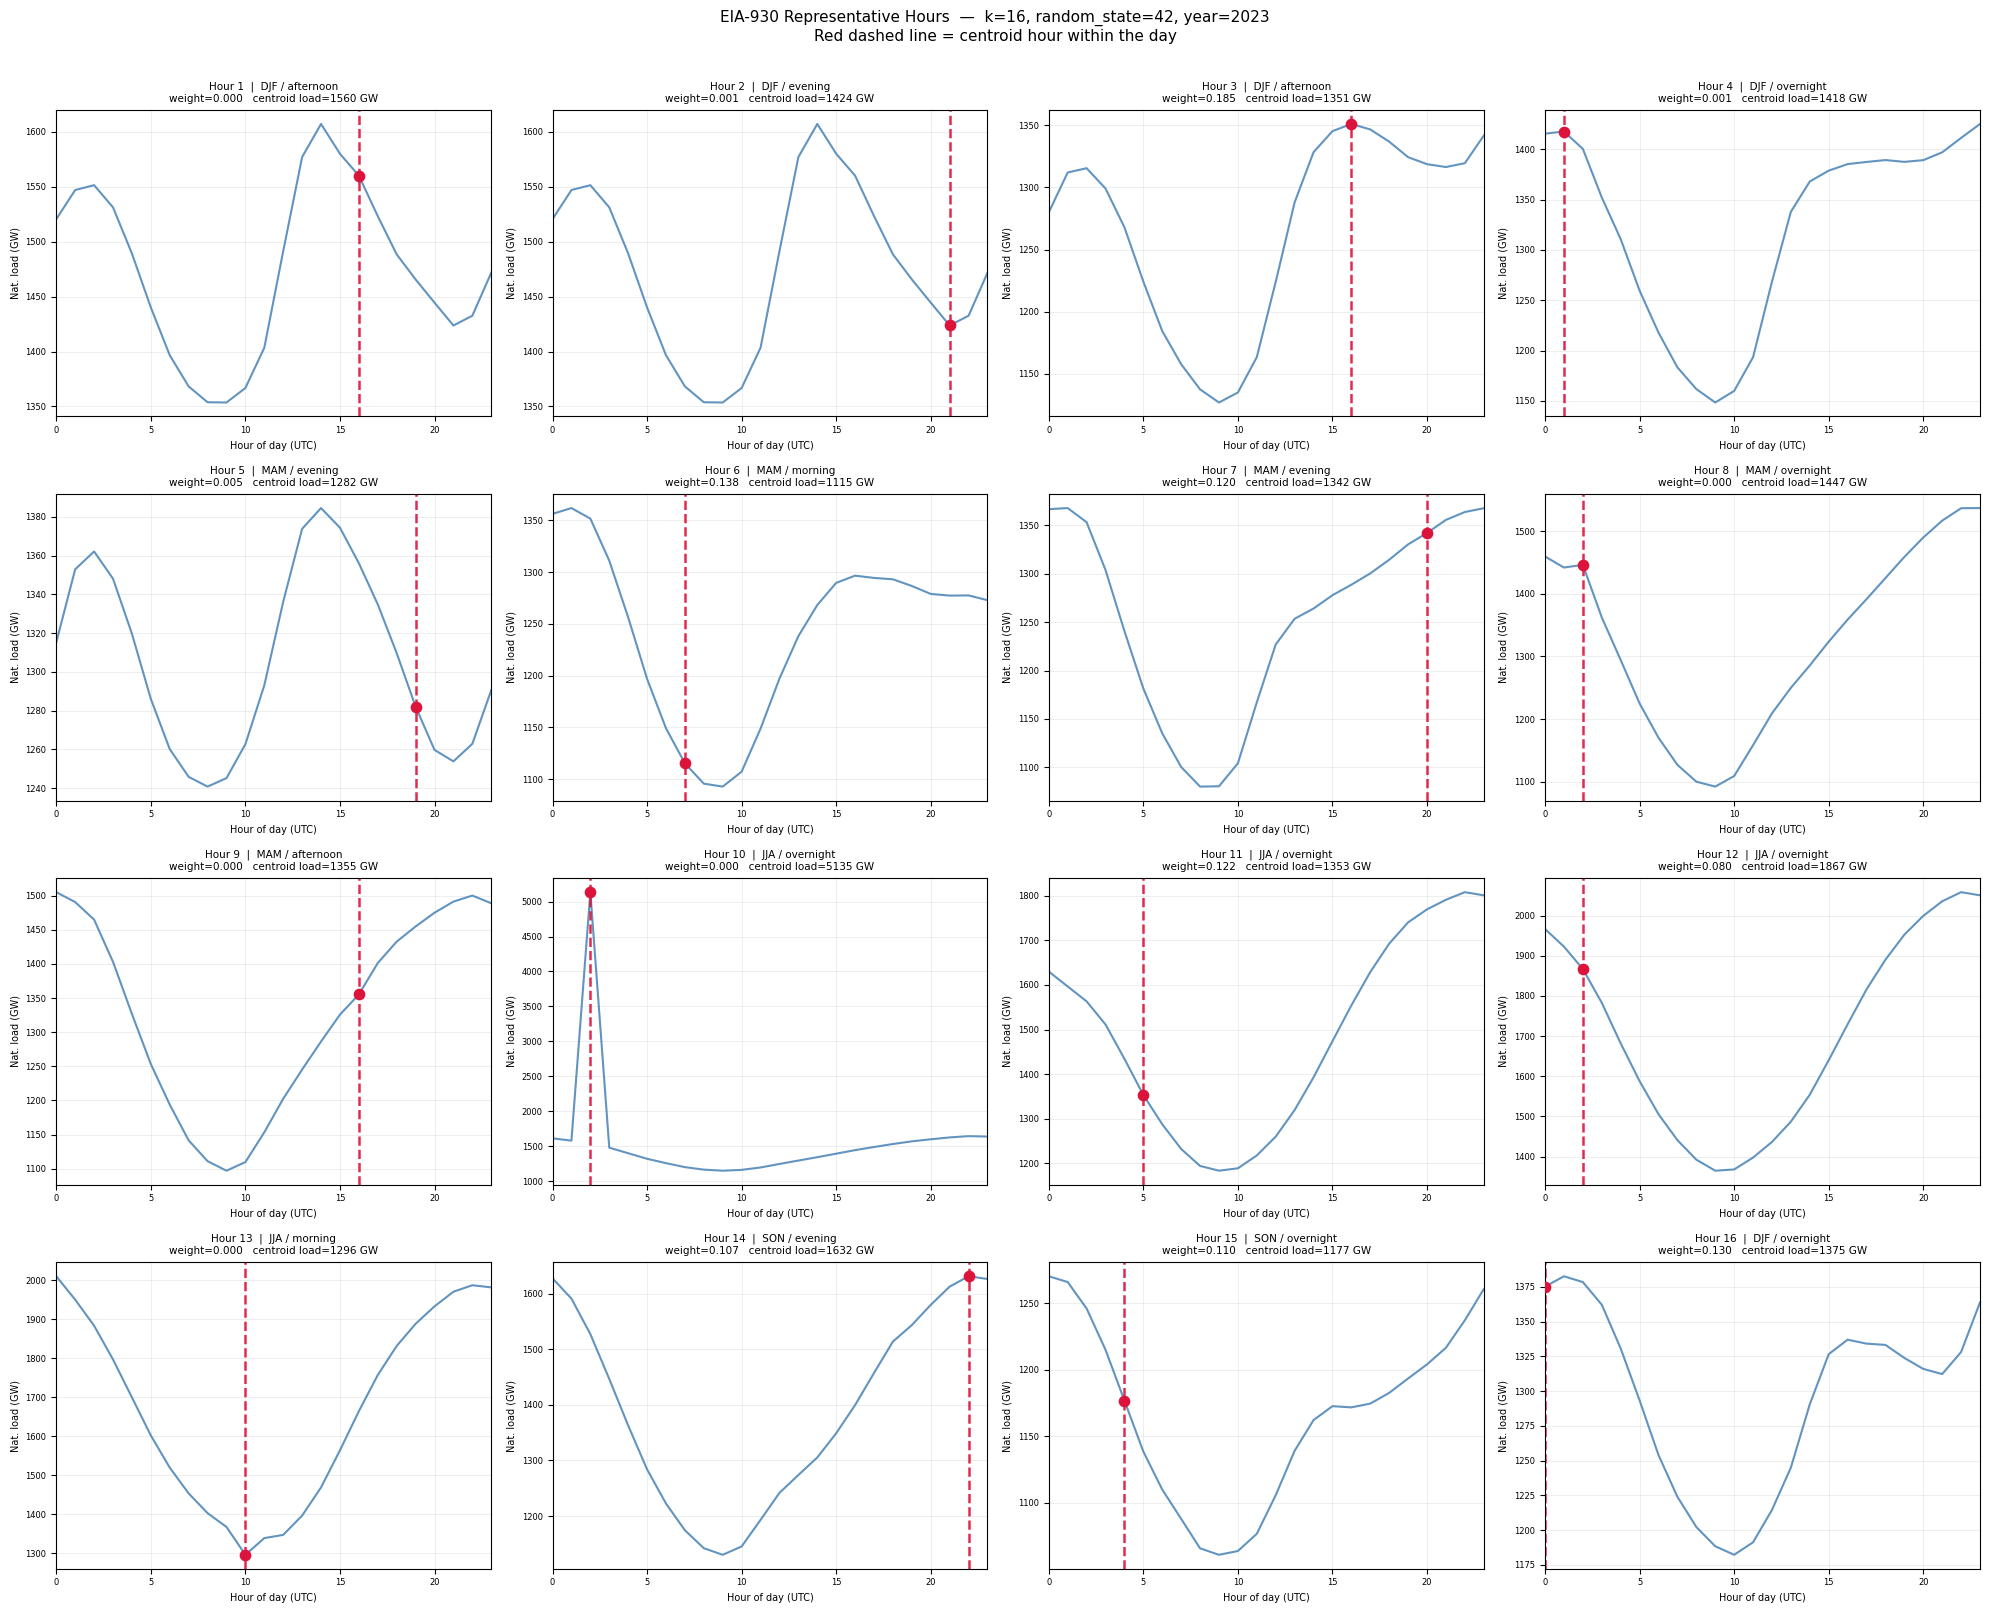

Saved: /Users/dylanhartman/Library/CloudStorage/OneDrive-UniversityofWyoming/Research/Energy Modeling/energy-map/data/processed/figures/11_representative_hours.png  (1.16 MB)


In [10]:
# --- Plot: 4×4 grid of centroid-day national load profiles ---

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes_flat = axes.flatten()

# Iterate panels in hour_id order
panels = sorted(cluster_info, key=lambda x: cluster_to_hour_id[x["cluster"]])

for ax, ci in zip(axes_flat, panels):
    h_id = cluster_to_hour_id[ci["cluster"]]
    ts   = ci["centroid_ts"]

    # 24-hour window starting at midnight UTC on the centroid day
    day_start = ts.normalize()                          # midnight UTC
    day_end   = day_start + pd.Timedelta(hours=23)
    day_mask  = (wide.index >= day_start) & (wide.index <= day_end)
    day_data  = wide.loc[day_mask]

    if len(day_data) == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"Hour {h_id}", fontsize=8)
        continue

    national_gw  = day_data.sum(axis=1).values / 1_000
    hour_of_day  = np.arange(len(day_data))

    ax.plot(hour_of_day, national_gw, color="steelblue", lw=1.5, alpha=0.85)

    # Highlight centroid hour
    ch = ts.hour
    if 0 <= ch < len(national_gw):
        ax.axvline(ch, color="crimson", lw=1.8, ls="--", alpha=0.9)
        ax.scatter([ch], [national_gw[ch]], color="crimson", s=55, zorder=6)

    ax.set_title(
        f"Hour {h_id}  |  {ci['season']} / {ci['time_of_day']}\n"
        f"weight={ci['weight']:.3f}   centroid load={ci['national_load_mw']/1000:.0f} GW",
        fontsize=7.5,
    )
    ax.set_xlabel("Hour of day (UTC)", fontsize=7)
    ax.set_ylabel("Nat. load (GW)",    fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_xlim(0, 23)
    ax.grid(True, alpha=0.3, lw=0.5)

fig.suptitle(
    f"EIA-930 Representative Hours  —  k={K_FINAL}, random_state={RANDOM_STATE}, year={YEAR}\n"
    "Red dashed line = centroid hour within the day",
    fontsize=11, y=1.005,
)
plt.tight_layout()

out_fig = PROCESSED / "figures" / "11_representative_hours.png"
out_fig.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_fig, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out_fig}  ({out_fig.stat().st_size / 1e6:.2f} MB)")

In [11]:
# --- Update network_metadata.json ---

meta_path = PROCESSED / "network_metadata.json"
with open(meta_path) as f:
    meta = json.load(f)

meta["hours_table"] = {
    "n_representative_hours": K_FINAL,
    "k_means_seed":           RANDOM_STATE,
    "date_range":             f"{YEAR}-01-01T00Z / {YEAR}-12-31T23Z",
    "n_bas_included":         N_BA,
    "wcss":                   {str(k): round(float(v), 2) for k, v in wcss.items()},
    "timestamp":              datetime.now(timezone.utc).isoformat(),
}

with open(meta_path, "w") as f:
    json.dump(meta, f, indent=4)

print(f"Updated: {meta_path}")
print(json.dumps(meta["hours_table"], indent=2))

Updated: /Users/dylanhartman/Library/CloudStorage/OneDrive-UniversityofWyoming/Research/Energy Modeling/energy-map/data/processed/network_metadata.json
{
  "n_representative_hours": 16,
  "k_means_seed": 42,
  "date_range": "2023-01-01T00Z / 2023-12-31T23Z",
  "n_bas_included": 67,
  "wcss": {
    "8": 18115.4,
    "16": 11494.86,
    "24": 8983.66
  },
  "timestamp": "2026-05-04T17:25:28.532480+00:00"
}


In [12]:
print("=" * 60)
print("HANDOFF CHECK")
print("=" * 60)

hours_check = pd.read_csv(PROCESSED / "e4st_hours.csv")
load_check  = pd.read_parquet(PROCESSED / "e4st_load_by_hour.parquet")
fig_path    = PROCESSED / "figures" / "11_representative_hours.png"

# e4st_hours.csv
n_rows      = len(hours_check)
weight_sum  = hours_check["weight"].sum()
ok_rows     = n_rows == K_FINAL
ok_weights  = abs(weight_sum - 1.0) < 1e-6

print(f"e4st_hours.csv rows       : {n_rows}  (expected {K_FINAL})  {'OK' if ok_rows else 'FAIL'}")
print(f"e4st_hours.csv weight sum : {weight_sum:.8f}  (expected 1.0)  {'OK' if ok_weights else 'FAIL'}")

# e4st_load_by_hour.parquet
expected_load_rows = K_FINAL * N_BA
ok_load_rows = len(load_check) == expected_load_rows
null_load    = int(load_check["load_mw"].isna().sum())
ok_no_null   = null_load == 0

print(f"e4st_load_by_hour shape   : {load_check.shape}  "
      f"(expected {expected_load_rows} = {K_FINAL}×{N_BA})  "
      f"{'OK' if ok_load_rows else 'WARN'}")
print(f"load_mw null values       : {null_load}  {'OK' if ok_no_null else 'FAIL'}")

# Figure
ok_fig = fig_path.exists()
print(f"figure PNG                : {'exists' if ok_fig else 'MISSING'}")

# File sizes
print("\nFile sizes:")
for fp in [PROCESSED / "e4st_hours.csv",
           PROCESSED / "e4st_load_by_hour.parquet",
           fig_path]:
    sz = f"{fp.stat().st_size / 1e6:.3f} MB" if fp.exists() else "MISSING"
    print(f"  {fp.name}: {sz}")

all_ok = ok_rows and ok_weights and ok_no_null and ok_fig
print()
print("=" * 60)
print("HANDOFF CONDITION MET" if all_ok else "HANDOFF CONDITION NOT MET — see issues above")
print("=" * 60)

HANDOFF CHECK
e4st_hours.csv rows       : 16  (expected 16)  OK
e4st_hours.csv weight sum : 1.00000002  (expected 1.0)  OK
e4st_load_by_hour shape   : (1072, 3)  (expected 1072 = 16×67)  OK
load_mw null values       : 0  OK
figure PNG                : exists

File sizes:
  e4st_hours.csv: 0.001 MB
  e4st_load_by_hour.parquet: 0.009 MB
  11_representative_hours.png: 1.158 MB

HANDOFF CONDITION MET
